In [86]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import joblib  # Modeli kaydetmek için
import seaborn as sns   
import psycopg2
import re
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report
import joblib

In [55]:

# 1. Veriyi Yükle ve Temizle
df = pd.read_csv('Sonhali.csv')


In [56]:
df = df.dropna()

In [57]:
df.columns

Index(['Kiyafet_Id', 'Yas', 'Baslik', 'Inceleme Metni', 'Derecelendirme',
       'Onerilme Durumu', 'Olumlu Geri Bildirim Sayisi', 'Bolum Adi',
       'Departman Adi', 'Sinif Adi', 'Yaş Grubu', 'Düşük_Puan_Mi'],
      dtype='object')

In [58]:
#Eksik Veri
df = df.dropna(subset=['Inceleme Metni'])

text.lower() (Küçük Harfe Çevirme):

Neden? Bilgisayar için "Harika" ve "harika" tamamen farklı iki kelimedir. Eğer hepsini küçültmezsek, model bu iki kelimeyi ayrı ayrı öğrenmek zorunda kalır. Veri setini gereksiz yere iki katına çıkarırız. Amacımız kelime standardizasyonudur.

re.sub(...) (Noktalama ve Sayıları Silme):

Neden? Duygu analizi yaparken "Elbise güzel." ile "Elbise güzel!!!" arasında bir fark yoktur; ikisi de olumludur. Ancak bilgisayar sondaki ünlemleri "farklı bir kelimeymiş" gibi algılar. Noktalama işaretleri ve sayılar (çoğu zaman) duygu barındırmayan "gürültü" (noise) verileridir. Bunları silerek modelin sadece anlamlı kelimelere odaklanmasını sağlarız.

In [59]:

def metin_temizle(text):
    # a. Her şeyi küçük harfe çevir
    text = text.lower()
    # b. Noktalama işaretlerini ve sayıları kaldır (Sadece harfler kalsın)
    text = re.sub(r'[^\w\s]', '', text) 
    text = re.sub(r'\d+', '', text)
    return text


In [60]:
df['Temiz_Metin'] = df['Inceleme Metni'].apply(metin_temizle)

In [61]:
X = df['Temiz_Metin']
y = df['Onerilme Durumu']

Modelimizin hedef değişkeni y olacak x ise bağımısız

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

1. TF (Term Frequency) - Kelime Sıklığı
Soru: "Bu kelime şu an incelediğim yorumda ne kadar sık geçiyor?"

Mantık: Bir kelime yorumun içinde ne kadar çok geçiyorsa, o yorumun konusu için o kadar önemlidir.

Örnek: Müşteri yorumunda 3 kere "kumaş" dediyse, bu yorum "kumaş" hakkındadır.

Formül: (Kelimenin yorumdaki sayısı) / (Yorumdaki toplam kelime sayısı)

2. IDF (Inverse Document Frequency) - Ters Belge Sıklığı
Soru: "Bu kelime tüm veri setinde (23.000 yorumun tamamında) ne kadar yaygın?"

Mantık: İşte sihir burada! Eğer bir kelime herkes tarafından kullanılıyorsa (örneğin: "elbise", "aldım", "ve"), bu kelime sıradandır ve puanı DÜŞÜRÜLMELİDİR (Cezalandırılır).

Amaç: Nadir bulunan kelimeleri (örneğin: "soluk", "dar", "iade") ödüllendirmek ve puanını ARTIRMAKTIR.

Formül: Toplam yorum sayısı / Kelimenin geçtiği yorum sayısı (Logaritması alınır).

Python'daki TfidfVectorizer komutu çalıştığında, kodunuz kelimeleri kelime olmaktan çıkarıp dev bir Sayı Matrisine dönüştürür.

In [63]:
#TF-IDF Nesnesini (Çevirmen) Oluşturuyoruz
# max_features=5000: En sık geçen 5000 kelimeyi sözlüğe al, gerisini at.

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Model Nesnesini Oluşturuyoruz
log_model = LogisticRegression()


In [64]:
X_train_tf = tfidf_vectorizer.fit_transform(X_train)

In [65]:
print(X_train_tf)  # (Eğitim örnek sayısı, Özellik sayısı)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 684866 stored elements and shape (16032, 5000)>
  Coords	Values
  (0, 3304)	0.11019003305508901
  (0, 4400)	0.07633768385048129
  (0, 1287)	0.135987435072459
  (0, 2862)	0.11314299348196236
  (0, 4368)	0.1323881204115685
  (0, 1937)	0.1975331037678947
  (0, 4458)	0.17296382053305406
  (0, 3494)	0.12869714622301368
  (0, 2217)	0.11573841142869935
  (0, 1466)	0.14533005981229521
  (0, 1602)	0.13355620127088966
  (0, 223)	0.0738615169542563
  (0, 4379)	0.08806962040699977
  (0, 3606)	0.13661719094371103
  (0, 132)	0.1488325446002291
  (0, 2374)	0.10196692335226716
  (0, 328)	0.1800827953087583
  (0, 1851)	0.09779235160424785
  (0, 3067)	0.20252076071326125
  (0, 956)	0.10438219814413487
  (0, 2822)	0.06232429202451126
  (0, 1425)	0.1002008086239004
  (0, 1807)	0.10313847418636882
  (0, 2881)	0.1567521338617836
  (0, 2943)	0.1147053202166162
  :	:
  (16030, 616)	0.12194362989499619
  (16030, 3675)	0.09353329861616658
  (16030, 2

In [66]:
kelime_listesi = tfidf_vectorizer.get_feature_names_out()
idf_degerleri = tfidf_vectorizer.idf_
print(idf_degerleri)
print(kelime_listesi)

[9.07296646 8.89064491 8.73649423 ... 8.19749773 8.60296284 8.89064491]
['_______' '________' '__________' ... 'zips' 'zone' 'zoom']


In [67]:
idf_tablosu = pd.DataFrame({
    'Kelime': kelime_listesi,
    'Nadirlik_Skoru (IDF)': tfidf_vectorizer.idf_
})

In [68]:
#kelimenin nadirlik skoruna göre en yüksek 20 kelimeyi yazdır
#genel olarak nadirlik skoru yüksek olan kelimeler daha az kullanılır
print(idf_tablosu.sort_values(by='Nadirlik_Skoru (IDF)', ascending=False).head(20))

           Kelime  Nadirlik_Skoru (IDF)
2949    overdress              9.583792
728     chestback              9.583792
3348     raincoat              9.583792
119        alpaca              9.583792
133         amadi              9.583792
2709          moo              9.583792
721   cheesecloth              9.583792
294         baily              9.583792
4235     survivor              9.583792
1549          feb              9.583792
2032      hoffman              9.583792
2250         joes              9.583792
3771     shirring              9.583792
2334    lambswool              9.583792
4457        tneck              9.583792
3744    shearling              9.583792
2894          ope              9.296110
884   complicated              9.296110
880     completed              9.296110
883     compliant              9.296110


In [69]:

def detayli_puan_analizi(satir_no, tfidf_matrix, vectorizer):
    # 1. İlgili cümlenin vektörünü al
    cumle_vektoru = tfidf_matrix[satir_no]
    
    # 2. Sadece puanı 0 olmayan (yani cümlede geçen) kelimelerin indekslerini bul
    # (coo_matrix formatı kullanıyoruz, data=puanlar, col=kelime_indeksleri)
    coo = cumle_vektoru.tocoo()
    
    data = []
    
    # 3. Her kelime için döngü
    for puan, kelime_indeksi in zip(coo.data, coo.col):
        # A. Kelimenin Adı
        kelime = vectorizer.get_feature_names_out()[kelime_indeksi]
        
        # B. IDF Değeri (Genel Önem - Tüm veri setinde ne kadar nadir?)
        idf_degeri = vectorizer.idf_[kelime_indeksi]
        
        # C. TF Değeri (Cümle İçi Yoğunluk)
        # Formül: TF = (TF-IDF Puanı) / IDF
        # Not: Sklearn L2 normalizasyonu yaptığı için bu "Normalize Edilmiş TF"dir.
        tf_degeri = puan / idf_degeri
        
        data.append({
            'Kelime': kelime,
            'TF-IDF (Sonuç)': puan,      # Modelin kullandığı nihai puan
            'IDF (Nadirlik)': idf_degeri, # Kelime ne kadar özel? (Yüksek = Nadir)
            'TF (Sıklık)': tf_degeri      # Cümlede ne kadar yoğun?
        })
    
    # 4. Tablo oluştur ve puana göre sırala
    df_analiz = pd.DataFrame(data).sort_values(by='TF-IDF (Sonuç)', ascending=False)
    
    # Tabloyu göster
    print(f"\n>>> ANALİZ EDİLEN CÜMLE (Index: {satir_no})")
    print(f"\"{X_train.iloc[satir_no]}\"") # Orijinal metni yazdır
    print("-" * 65)
    print(df_analiz.round(4).to_markdown(index=False)) # 4 basamak yuvarla

# --- ÖRNEK KULLANIM ---
# Eğitim setinden rastgele bir yorum seçip analiz edelim (Örn: 10. satır)
detayli_puan_analizi(10, X_train_tf, tfidf_vectorizer)


>>> ANALİZ EDİLEN CÜMLE (Index: 10)
"this dress is simply gorgeous the slit is just right the colors are great and most of all the fabric is very comfy i highly recommend"
-----------------------------------------------------------------
| Kelime    |   TF-IDF (Sonuç) |   IDF (Nadirlik) |   TF (Sıklık) |
|:----------|-----------------:|-----------------:|--------------:|
| slit      |           0.3904 |           6.5393 |        0.0597 |
| simply    |           0.3652 |           6.1181 |        0.0597 |
| highly    |           0.2972 |           4.9786 |        0.0597 |
| most      |           0.2599 |           4.3545 |        0.0597 |
| comfy     |           0.2583 |           4.3263 |        0.0597 |
| is        |           0.2452 |           1.3692 |        0.1791 |
| gorgeous  |           0.2448 |           4.1004 |        0.0597 |
| recommend |           0.2442 |           4.0907 |        0.0597 |
| right     |           0.2159 |           3.6168 |        0.0597 |
| the       |

In [70]:
X_test_tf = tfidf_vectorizer.transform(X_test)

In [71]:
log_model.fit(X_train_tf, y_train)

LogisticRegression()

In [72]:
y_pred = log_model.predict(X_test_tf)

In [73]:
# ROC eğrisi için olasılık değerleri
y_prob = log_model.predict_proba(X_test_tf)[:, 1]

([<matplotlib.axis.YTick at 0x70de60d6f890>,
 [Text(0, 0.5, 'Önermiyor'), Text(0, 1.5, 'Öneriyor')])

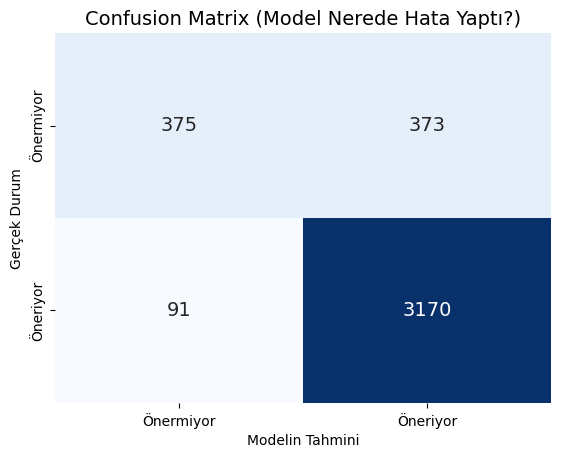

In [74]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title('Confusion Matrix (Model Nerede Hata Yaptı?)', fontsize=14)
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Durum')
# Etiketleri ekleyelim
plt.xticks([0.5, 1.5], ['Önermiyor', 'Öneriyor'])
plt.yticks([0.5, 1.5], ['Önermiyor', 'Öneriyor'])

In [75]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) # Eğri altındaki alan (1'e ne kadar yakınsa o kadar iyi)

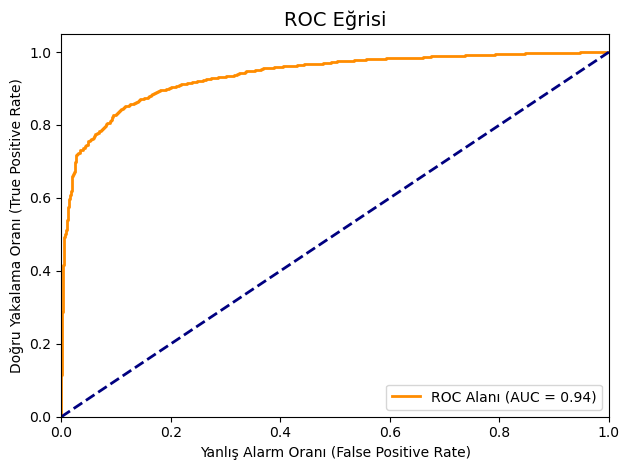

In [76]:
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Alanı (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Rastgele tahmin çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Alarm Oranı (False Positive Rate)')
plt.ylabel('Doğru Yakalama Oranı (True Positive Rate)')
plt.title('ROC Eğrisi', fontsize=14)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [77]:
# average='binary' dediğimiz için varsayılan olarak "1" (Pozitif) sınıfını baz alır.
kesinlik = precision_score(y_test, y_pred)
duyarlilik = recall_score(y_test, y_pred)
f1_skoru = f1_score(y_test, y_pred)

print(f"--- TEMEL METRİKLER (Pozitif Sınıf: 'Öneriyor') ---")
print(f"Precision (Kesinlik): %{kesinlik*100:.2f}")
print(f"Recall (Duyarlılık) : %{duyarlilik*100:.2f}")
print(f"F1 Score (Denge)    : %{f1_skoru*100:.2f}")

print("\n" + "="*50 + "\n")

# 2. Detaylı Sınıflandırma Raporu (Her iki sınıf için)
# Bu rapor çok daha önemlidir çünkü "Önermiyor" (0) sınıfındaki başarımızı da gösterir.
print("--- DETAYLI SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred, target_names=['Önermiyor (0)', 'Öneriyor (1)']))

--- TEMEL METRİKLER (Pozitif Sınıf: 'Öneriyor') ---
Precision (Kesinlik): %89.47
Recall (Duyarlılık) : %97.21
F1 Score (Denge)    : %93.18


--- DETAYLI SINIFLANDIRMA RAPORU ---
               precision    recall  f1-score   support

Önermiyor (0)       0.80      0.50      0.62       748
 Öneriyor (1)       0.89      0.97      0.93      3261

     accuracy                           0.88      4009
    macro avg       0.85      0.74      0.77      4009
 weighted avg       0.88      0.88      0.87      4009




Support Sütunnuana bakıldığında Önermiyor için yeterince veri yok
Eğitim seti dengeli değil

Öneriyor (1): 3261 tane örnek var. (Eğitimde baskın olan grup)

Önermiyor (0): 748 tane örnek var. (Azınlık)

In [78]:
#modelin dengeli çalışması için class_weight parametresini 'balanced' olarak ayarlıyoruz
log_model_dengeli = LogisticRegression(class_weight='balanced')

In [79]:
log_model_dengeli.fit(X_train_tf, y_train)

LogisticRegression(class_weight='balanced')

In [80]:
y_pred_dengeli = log_model_dengeli.predict(X_test_tf)

In [81]:
# ROC eğrisi için olasılık değerleri
y_prob_dengeli = log_model_dengeli.predict_proba(X_test_tf)[:, 1]

([<matplotlib.axis.YTick at 0x70de5c7ca990>,
 [Text(0, 0.5, 'Önermiyor'), Text(0, 1.5, 'Öneriyor')])

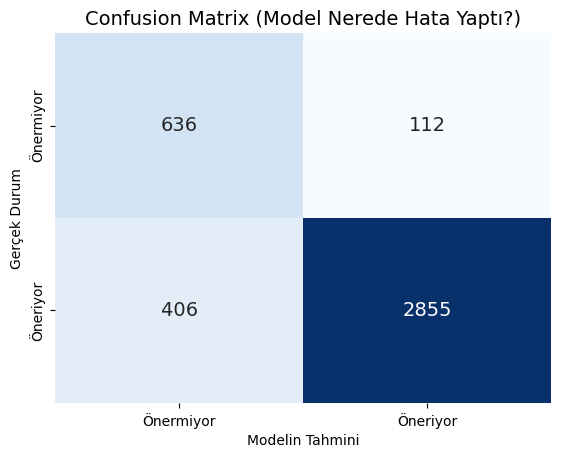

In [82]:
cm = confusion_matrix(y_test, y_pred_dengeli)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title('Confusion Matrix (Model Nerede Hata Yaptı?)', fontsize=14)
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Durum')
# Etiketleri ekleyelim
plt.xticks([0.5, 1.5], ['Önermiyor', 'Öneriyor'])
plt.yticks([0.5, 1.5], ['Önermiyor', 'Öneriyor'])

In [83]:
fpr_dengeli, tpr_dengeli, thresholds = roc_curve(y_test, y_prob_dengeli)
roc_auc = auc(fpr_dengeli, tpr_dengeli) # Eğri altındaki alan (1'e ne kadar yakınsa o kadar iyi)

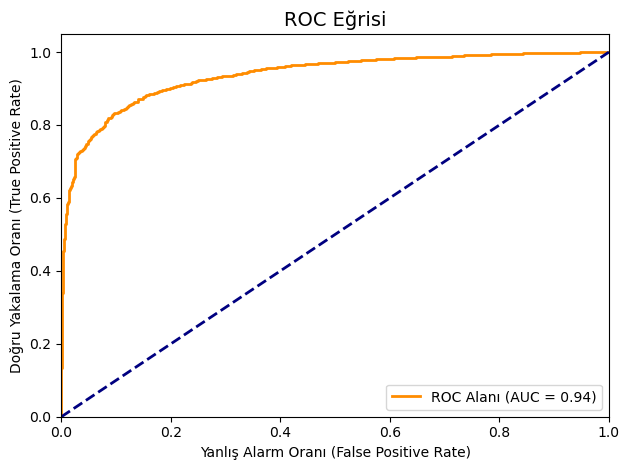

In [84]:
plt.plot(fpr_dengeli, tpr_dengeli, color='darkorange', lw=2, label=f'ROC Alanı (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Rastgele tahmin çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Alarm Oranı (False Positive Rate)')
plt.ylabel('Doğru Yakalama Oranı (True Positive Rate)')
plt.title('ROC Eğrisi', fontsize=14)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [85]:
# average='binary' dediğimiz için varsayılan olarak "1" (Pozitif) sınıfını baz alır.
kesinlik_dengeli = precision_score(y_test, y_pred_dengeli)
duyarlilik_dengeli = recall_score(y_test, y_pred_dengeli)
f1_skoru_dengeli = f1_score(y_test, y_pred_dengeli)

print(f"--- TEMEL METRİKLER (Pozitif Sınıf: 'Öneriyor') ---")
print(f"Precision (Kesinlik): %{kesinlik_dengeli*100:.2f}")
print(f"Recall (Duyarlılık) : %{duyarlilik_dengeli*100:.2f}")
print(f"F1 Score (Denge)    : %{f1_skoru_dengeli*100:.2f}")

print("\n" + "="*50 + "\n")

# 2. Detaylı Sınıflandırma Raporu (Her iki sınıf için)
# Bu rapor çok daha önemlidir çünkü "Önermiyor" (0) sınıfındaki başarımızı da gösterir.
print("--- DETAYLI SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred_dengeli, target_names=['Önermiyor (0)', 'Öneriyor (1)']))

--- TEMEL METRİKLER (Pozitif Sınıf: 'Öneriyor') ---
Precision (Kesinlik): %96.23
Recall (Duyarlılık) : %87.55
F1 Score (Denge)    : %91.68


--- DETAYLI SINIFLANDIRMA RAPORU ---
               precision    recall  f1-score   support

Önermiyor (0)       0.61      0.85      0.71       748
 Öneriyor (1)       0.96      0.88      0.92      3261

     accuracy                           0.87      4009
    macro avg       0.79      0.86      0.81      4009
 weighted avg       0.90      0.87      0.88      4009



In [92]:
#modeli kaydet
joblib.dump(log_model_dengeli, 'log_model_dengeli.pkl')

['log_model_dengeli.pkl']

In [93]:
#TF-IDF vektörleştiriciyi kaydet modelin sözlüğü için
joblib.dump(tfidf_vectorizer, 'vektorlestirici.pkl')

['vektorlestirici.pkl']

In [94]:
#modeli geri yükle
yuklenen_model = joblib.load('log_model_dengeli.pkl')
yuklenen_vektor = joblib.load('vektorlestirici.pkl')

In [107]:
#deneme_yorum = "The quality is very poor"
deneme_yorum = "The quality is very good. I am very satisfied with my purchase."

In [108]:
#Önce yüklediğimiz sözlük ile sayıya çevir (Transform)
sayisal_veri = yuklenen_vektor.transform([deneme_yorum])

In [109]:
tahmin = yuklenen_model.predict(sayisal_veri)[0]

print(tahmin)

1
